# Stage 4 — Model Comparison: Supporting Visualizations

Four charts for the comparison already documented in `reports/stage4_model_comparison.md` — a visual companion, not a re-analysis. Every number plotted here comes from that same run.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

BASE_DIR = Path("..").resolve()
sys.path.insert(0, str(BASE_DIR))

from analysis.stage4_model_comparison import fit_all_for_comparison

with open(BASE_DIR / "reports" / "stage4_model_comparison.json") as f:
    results = json.load(f)

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK_MUTED, NEUTRAL = "#0b0b0b", "#52514e", "#f0efec"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.6,
    "font.size": 10.5, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "figure.dpi": 110,
})

MODEL_COLORS = {
    "Baseline (production RF, 11 features)": ORANGE,
    "Logistic Regression (8 features)": BLUE,
    "Random Forest (8 features)": AQUA,
    "Gradient Boosting (8 features)": VIOLET,
}
SHORT_NAMES = {
    "Baseline (production RF, 11 features)": "Baseline RF",
    "Logistic Regression (8 features)": "Logistic Regression",
    "Random Forest (8 features)": "Random Forest",
    "Gradient Boosting (8 features)": "Gradient Boosting",
}
[r["name"] for r in results]

['Baseline (production RF, 11 features)',
 'Logistic Regression (8 features)',
 'Random Forest (8 features)',
 'Gradient Boosting (8 features)']

## 1. Model Performance Comparison

At-a-glance view of the five test-set metrics behind the production decision.

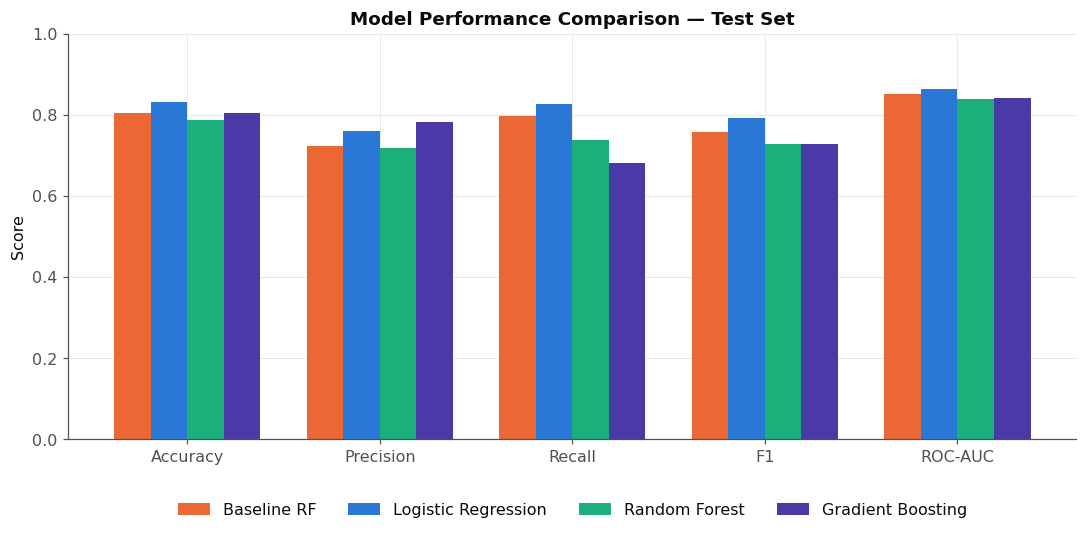

In [2]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
width = 0.19
for i, r in enumerate(results):
    values = [r[m] for m in metrics]
    offset = (i - 1.5) * width
    ax.bar(x + offset, values, width, label=SHORT_NAMES[r["name"]], color=MODEL_COLORS[r["name"]])
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison \u2014 Test Set")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

- Logistic Regression leads on four of five metrics — accuracy, recall, F1, and ROC-AUC — losing only precision to Gradient Boosting (0.783 vs. 0.760)
- The spread across all four models is modest: no metric varies by more than roughly 10 percentage points
- Random Forest (8 features, untuned) is the weakest model on every metric, despite sharing Logistic Regression's schema — the algorithm, not the feature set, explains the gap here

**Takeaway**

Performance alone makes a case for Logistic Regression, but not an overwhelming one — the margins are real, not dramatic. The next three charts check whether stability and generalization reinforce or undercut that case.

## 2. Cross-Validation Stability

Average CV score hides variance. This shows the actual spread across the same five folds used in Stage 4.

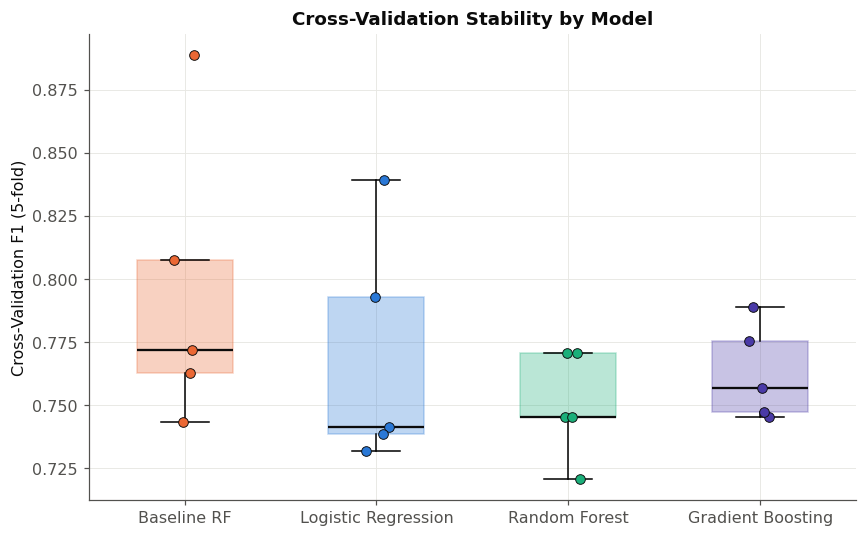

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
data = [r["cv_scores"] for r in results]
labels = [SHORT_NAMES[r["name"]] for r in results]

bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.5, showfliers=False)
for patch, r in zip(bp["boxes"], results):
    color = MODEL_COLORS[r["name"]]
    patch.set_facecolor(color)
    patch.set_alpha(0.30)
    patch.set_edgecolor(color)
for median in bp["medians"]:
    median.set_color(INK)
    median.set_linewidth(1.5)

rng = np.random.default_rng(42)
for i, r in enumerate(results):
    jitter = rng.uniform(-0.07, 0.07, size=len(r["cv_scores"]))
    ax.scatter(np.full(len(r["cv_scores"]), i + 1) + jitter, r["cv_scores"],
               color=MODEL_COLORS[r["name"]], edgecolor=INK, linewidth=0.6, zorder=3, s=40)

ax.set_ylabel("Cross-Validation F1 (5-fold)")
ax.set_title("Cross-Validation Stability by Model")
plt.tight_layout()
plt.show()

- Random Forest and Gradient Boosting have the tightest fold-to-fold spread (std ≈ 0.017–0.019) — but that consistency centers on a lower score band
- Logistic Regression's folds range wider (std ≈ 0.041) yet its worst fold (0.732) still beats the median fold of both tree ensembles
- The baseline has the widest spread (std ≈ 0.051) despite being the only tuned model — `RandomizedSearchCV` optimized the average fold, not the worst one

**Takeaway**

Tight variance without competitive scores isn't real stability — it's consistency around a weaker answer. Logistic Regression's wider spread still clears the other models' typical fold, which matters more for production reliability than a narrow box around a lower number.

## 3. Train vs. Test Performance

Where does each model sit on the overfitting–underfitting spectrum? The gap between train and test F1 answers that directly.

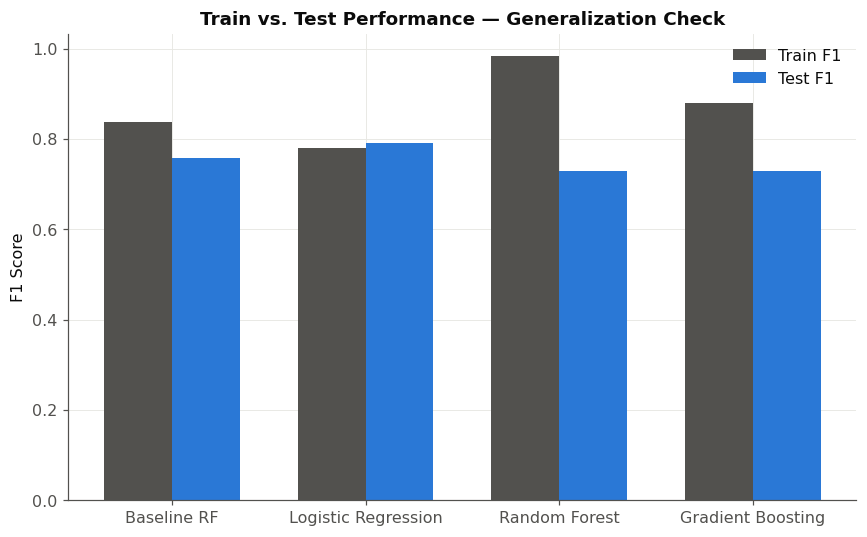

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results))
width = 0.35
train_vals = [r["train_f1"] for r in results]
test_vals = [r["f1"] for r in results]
ax.bar(x - width / 2, train_vals, width, label="Train F1", color=INK_MUTED)
ax.bar(x + width / 2, test_vals, width, label="Test F1", color=BLUE)
ax.set_xticks(x)
ax.set_xticklabels([SHORT_NAMES[r["name"]] for r in results])
ax.set_ylabel("F1 Score")
ax.set_title("Train vs. Test Performance \u2014 Generalization Check")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

- Random Forest's train F1 (0.984) towers over its test F1 (0.729) — a +0.255 gap from unlimited-depth trees memorizing 712 rows
- Logistic Regression is the only model where the test bar is not shorter than the train bar (0.792 vs. 0.780, a −0.012 gap) — no overfitting signature at all
- Gradient Boosting shows a smaller but still real gap (+0.150); the tuned baseline's gap (+0.079) is the mildest of the three ensembles, but tuning was needed to get there

**Takeaway**

Gap size tracks model capacity, not algorithm family. The two untuned tree ensembles memorize; the linear model and the tuned baseline both generalize, for different reasons — one because it lacks the capacity to overfit, the other because a search grid closed most of the gap.

## 4. ROC Curve Comparison

Overlaying all four models' ROC curves on the identical 179-row test set — the same rows Stage 4's methodology fixed across every model.

In [5]:
comparison = fit_all_for_comparison()

Best RF params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10}
Best RF CV F1:  0.7711


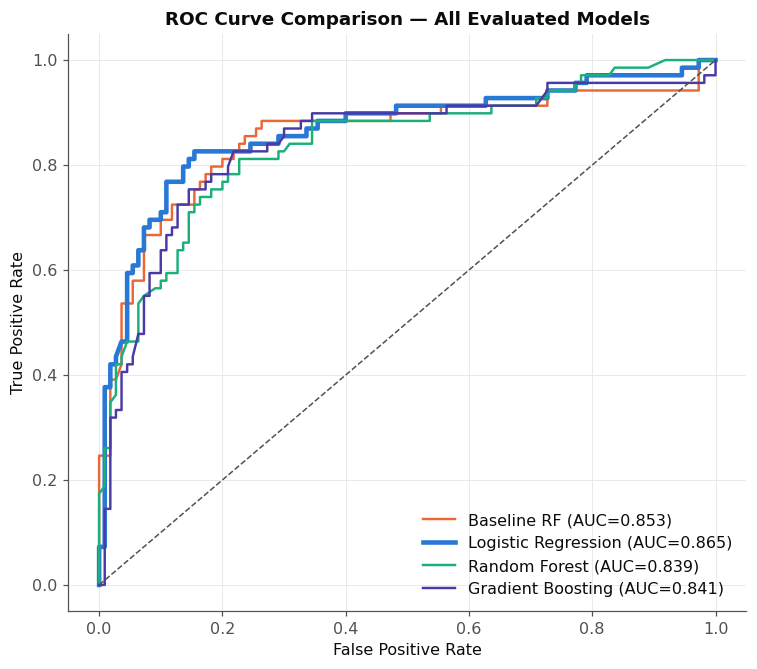

In [6]:
fig, ax = plt.subplots(figsize=(7, 6.2))
for name, d in comparison.items():
    fpr, tpr, _ = roc_curve(d["y_test"], d["y_proba"])
    auc = roc_auc_score(d["y_test"], d["y_proba"])
    lw = 3 if "Logistic Regression" in name else 1.6
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=lw, label=f"{SHORT_NAMES[name]} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison \u2014 All Evaluated Models")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

- All four curves cluster tightly — AUC ranges from 0.839 (Random Forest) to 0.865 (Logistic Regression), a 0.026 spread
- Logistic Regression's curve (bold) sits at or above the other three across nearly the full range, but the margin over the tuned baseline is thin, especially at low false-positive rates
- Random Forest's curve is the weakest through the middle of the range, consistent with it trailing on every metric in Section 1

**Takeaway**

ROC-AUC alone would have made this a close call — a 0.026 spread across four models is not a decisive signal by itself. Stage 4's actual recommendation leaned as much on stability (Section 2), generalization (Section 3), inference speed, and interpretability as on this curve; full reasoning in `reports/stage4_model_comparison.md`.